## KMeans from scratch

In [48]:
import numpy as np 
import matplotlib.pyplot as plt
import heapq

In [49]:
class KMeans:
    def __init__(self, k=3, X=None, y=None):
        self.k = k 
        self.X = X
        self.y = y
        
    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self.X = X
        self.y = y 
        
    def set_k(self, k):
        self.k = k    
    
    def return_k(self, dist):
        heap = [] 
        for i in range(len(dist)):
            heapq.heappush(heap, (-dist[i], self.y[i][0]))
            if len(heap) > self.k:
                heapq.heappop(heap) 
        return heap
    
    def calc_dist(self, X: np.ndarray) -> list:
        query = X[0]
        dist = np.zeros((self.X.shape[0]))
        for i in range(self.X.shape[0]):
            temp = 0
            for j in range(self.X.shape[1]):
                temp += (query[j] - self.X[i, j]) ** 2
            dist[i] = temp 
        return self.return_k(dist)

In [50]:
class KMeansClassification(KMeans):
    def __init__(self, k=3, X=None, y=None):
        super().__init__(k, X, y)
        
    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        super().fit(X, y)
        
    def predict(self, X: np.ndarray) -> np.ndarray:
        k_neighbors = self.calc_dist(X)
        classes = {}
        for neighbor in k_neighbors:
            classes[neighbor[1]] = classes.get(neighbor[1], 0) + 1
        return max(classes, key=classes.get)

In [51]:
class KMeansRegression(KMeans):
    def __init__(self, k=3, X=None, y=None):
        super().__init__(k, X, y)
        
    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        super().fit(X, y)
        
    def predict(self, X: np.ndarray) -> np.ndarray:
        k_neighbors = self.calc_dist(X)
        total = 0
        for neighbor in k_neighbors:
            total += neighbor[1]
        return np.array([[total / self.k]])

In [68]:
X_noisy = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6]]) + np.random.normal(0, 0.5, (5, 2))
y_noisy = np.array([[0], [0], [1], [1], [1]])

model = KMeansClassification(k=3)
model.fit(X_noisy, y_noisy)

In [69]:
X_new = np.array([[3, 3.5]])
res = model.predict(X_new)
print(res)

0


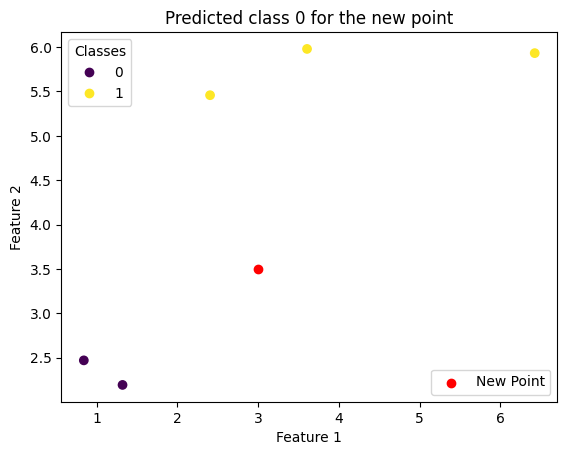

In [70]:
scatter = plt.scatter(X_noisy[:, 0], X_noisy[:, 1], c=y_noisy[:, 0], cmap='viridis')
plt.scatter(X_new[:, 0], X_new[:, 1], c='red', label='New Point')
legend1 = plt.legend(*scatter.legend_elements(), title="Classes", loc="upper left")
plt.gca().add_artist(legend1)

# Add the second legend for the 'New Point'
plt.legend(loc="lower right")
plt.title(f"Predicted class {res} for the new point")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [71]:
X_3d_noisy = np.array([[1, 2, 3], [2, 3, 4], [3, 4, 5], [4, 5, 6], [5, 6, 7]]) + np.random.normal(0, 0.5, (5, 3))
y_3d_noisy = np.array([[0], [0], [1], [1], [1]])

In [73]:
model = KMeansClassification(k=3)
model.fit(X_3d_noisy, y_3d_noisy)

In [74]:
X_new_3d = np.array([[3, 4, 5]])
res_3d = model.predict(X_new_3d)
print(res_3d)

1


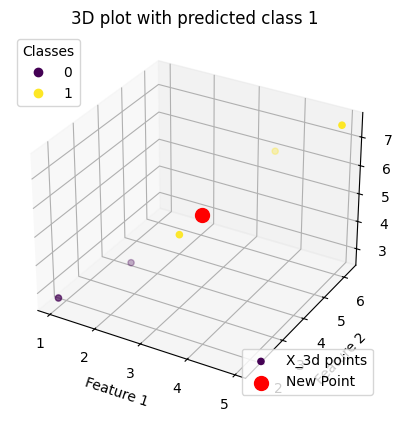

In [76]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_3d_noisy[:, 0], X_3d_noisy[:, 1], X_3d_noisy[:, 2],
    c=y_3d_noisy[:, 0], cmap='viridis', label='X_3d points'
 )
ax.scatter(
    X_new_3d[:, 0], X_new_3d[:, 1], X_new_3d[:, 2],
    c='red', s=100, label='New Point'
 )

legend1 = ax.legend(*scatter.legend_elements(), title='Classes', loc='upper left')
ax.add_artist(legend1)
ax.legend(loc='lower right')
ax.set_title(f'3D plot with predicted class {res_3d}')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
plt.show()

In [77]:
model_reg = KMeansRegression(k=3)
model_reg.fit(X_3d_noisy, y_3d_noisy)

In [80]:
X_new_3d = np.array([[3, 4, 5]])
res_3d_reg = model_reg.predict(X_new_3d)
print(res_3d_reg, np.round(res_3d_reg))

[[0.66666667]] [[1.]]


Text(0.5, 0, 'Feature 3')

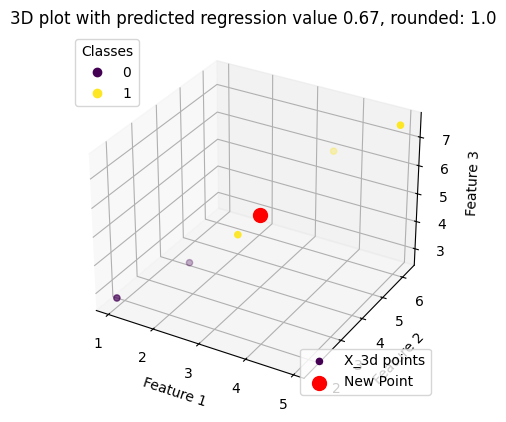

In [82]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X_3d_noisy[:, 0], X_3d_noisy[:, 1], X_3d_noisy[:, 2],
    c=y_3d_noisy[:, 0], cmap='viridis', label='X_3d points'
 )
ax.scatter(
    X_new_3d[:, 0], X_new_3d[:, 1], X_new_3d[:, 2],
    c='red', s=100, label='New Point'
    )
legend1 = ax.legend(*scatter.legend_elements(), title='Classes', loc='upper left')
ax.add_artist(legend1)
ax.legend(loc='lower right')
ax.set_title(f'3D plot with predicted regression value {res_3d_reg[0][0]:.2f}, rounded: {np.round(res_3d_reg[0][0])}')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')